This notebook illustrates statistical distributions using four problems.

The standard library `Statistics` provides basic statistics functionality.

In [1]:
using Statistics

We will make plots and evaluate definite integrals numerically.  The packages `Plots` and `QuadGK` need to be installed separately.  It is good practice to do the installation in a Julia environment, prior to running the Jupyter notebook

In [2]:
using Plots

In [3]:
using QuadGK

# Four Problems

We distinguish between discrete and continuous random variables:

* A *discrete* random variable returns values in a discrete set.

* A *continuous* random variable returns values in a continuous set.

## 1. The Rolling Dice Problem

We roll a fair 6-sided die ten times.

1. What is the expected value of the sum of the outcomes?

2. What is the variation in the expected value?

### Solution: the discrete uniform distribution

In rolling a fair 6-sided die, 
every side has equal probability of $\frac{1}{6}$.

The mean value of one throw is 7/2, computed as
$$
   \mu = 1 \left( \frac{1}{6} \right) + 2 \left( \frac{1}{6} \right)
       + 3 \left( \frac{1}{6} \right) + 4 \left( \frac{1}{6} \right)
       + 5 \left( \frac{1}{6} \right) + 6 \left( \frac{1}{6} \right)
       = 21/6.
$$

This implies that after 10 rolls, we may expect the sum to be 35.

The variance is $35/12 \approx 2.9166$, computed as
$$
   \sigma^2 = \frac{1}{6} \sum_{i=1}^6 \left( i - \frac{7}{2} \right)^2.
$$

For one roll, we thus have $3.5 \pm 2.9$.

For ten rolls, we expect $35 \pm 29$.

Let us first practice some useful computations.

In [4]:
mytuple = (1,2,3,4,5,6)

(1, 2, 3, 4, 5, 6)

In [5]:
rand(mytuple)

3

In [6]:
rolls = Array([rand(mytuple) for i=1:10])

10-element Vector{Int64}:
 3
 2
 2
 2
 2
 3
 1
 2
 1
 1

In [7]:
mean(rolls)

1.9

Do `?Statistics.mean` to see the documentation of the `mean` function of the `Statistics` module.  The standard deviation is computed with the function `std`.

In [8]:
std(rolls)

0.7378647873726218

Let us know do this for a million rolls.  With the semicolon `;` we suppress the output.

In [9]:
n = 10^6;
rolls = Array([rand(mytuple) for i=1:n]);
mean(rolls)

3.498721

This is close enough to the value of `3.5` which we can compute analytically.

In [10]:
std(rolls)

1.7079593909939084

The `std()` returns the square root of the variance $\sigma^2$.  To compute $\sigma$, take the square of the outcome of `std()`.

In [11]:
std(rolls)^2

2.9171252812842825

Also this number is sufficiently close to the value of $35/12 \approx 2.9$, computed analytically.

## 2. The Life Span Problem

Suppose a light bulb has an average life span of 1000 hours,
with a standard deviation of 400 hours.

Assuming a normal distribution,

what is the probability that a bulb lasts 2000 hours or longer?

### Solution: the normal distribution

$$
   P(X > 2) = \int_2^\infty 
   \frac{1}{\sigma \sqrt{2 \pi}} e^{-(x-\mu)^2/2\sigma^2}
   \quad \mbox{ for } \mu = 1, \sigma = 0.4
$$

We normalize the data, setting 1000 to 1, and then the standard deviation is 0.4.

In [12]:
f(x) = (1/(0.4*sqrt(2*pi)))*exp(-(x-1)^2/(2*0.4^2))

f (generic function with 1 method)

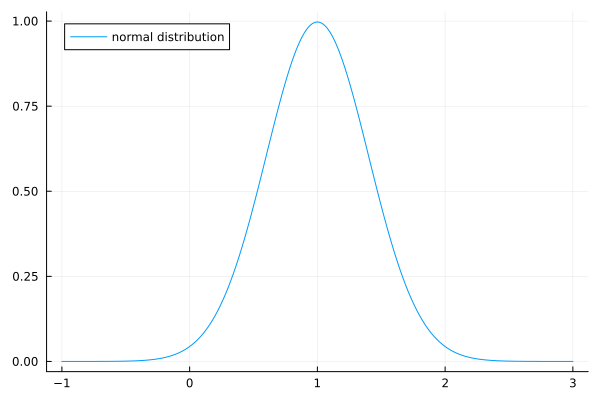

In [13]:
r = -1:0.01:3
fr = [f(t) for t in r]
plot(r,fr,label="normal distribution",legend=:topleft)

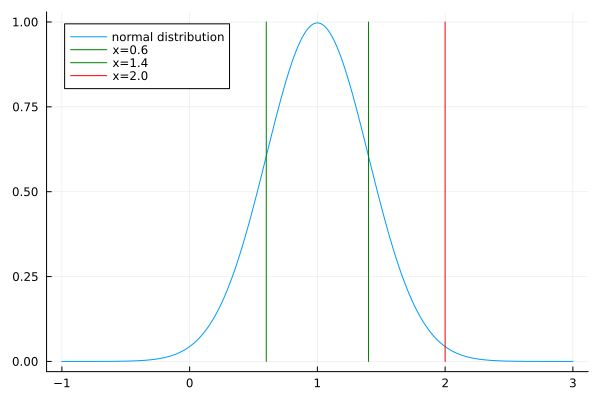

In [14]:
plot!([0.6],[1.0], line=(:sticks), color="green", label="x=0.6")
plot!([1.4],[1.0], line=(:sticks), color="green", label="x=1.4")
plot!([2.0],[1.0], line=(:sticks), color="red", label="x=2.0")

In [15]:
val, err = quadgk(f, 2.0, 100.0, rtol=1.0e-8)

(0.006209665325776137, 2.981577782577757e-12)

The probability that a light bulb last 2000 hours or longer is 0.0062.

## 3. The Staffing Problem

On average, for every three staffers who are emailed for a shift,
only one shows up.  

How many staffers must be emailed to guarantee at least 20 show up,

with a confidence of 90%?

### Solution: the binomial distribution

Observe: $1/3 = p$ is the probability of a presence.
Of $n$ emails sent,  the probability that $k$ are present is

$$
   p(k) = \left( \begin{array}{c} n \\ k \end{array} \right)
          p^k (1 - p)^k,
$$
where the factor
$\left( \begin{array}{c} n \\ k \end{array} \right)$
equals all subsets of size $k$ out of a total of $n$.



Find $n$ so that the probability that less than 20 are present
$<$ 10\%.

$$
   \sum_{k=0}^{19} p(k) = \sum_{k=0}^{19} 
   \left( \begin{array}{c} n \\ k \end{array} \right)
   \left( \frac{1}{3} \right)^k
   \left( \frac{2}{3} \right)^{n-k} < 0.1
$$

Using Julia as a calculator to evaluate
$$
   \sum_{k=0}^{19} p(k) = \sum_{k=0}^{19} 
   \left( \begin{array}{c} n \\ k \end{array} \right)
   \left( \frac{1}{3} \right)^k
   \left( \frac{2}{3} \right)^{n-k}
$$

In [16]:
c(n,k) = factorial(n)/(factorial(k)*factorial(n-k))

c (generic function with 1 method)

In [17]:
f(n) = sum([c(big(n),big(k))*(1/3)^k*(2/3)^(n-k) for k=0:19])

f (generic function with 1 method)

In [18]:
f(60)

0.4515887757895708606605488541657551888428570826529118815820649236777777414130989

In [19]:
f(73)

0.1136505489356501670001962500819069385931425225127100118726585530835343693101465

In [20]:
f(74)

0.09950717529629136931505734747805948509408329660351445748333396563794101338227414

At least 74 emails must be sent to have 20 present with 90% confidence.

## 4. The Arrival Problem

A market has 60 customers per hour on average.

What is the probability that more than 20 customers check out 

in one quarter hour?

### Solution: the Poisson distribution.

Observe: time is continuous.  Time unit = one quarter of an hour.

The random variable $X$ is the number of arrivals per quarter hour.

On average: 15 customers per quarter hour.

The Poisson distribution has parameter $\lambda$
and average $\mu = \lambda T$, 
where $T$ is the time unit.

$$
   p(k) = \frac{(\lambda T)^k}{k!} e^{-\lambda T} \quad
   F(x) = e^{-\lambda T} \sum_{k=0}^x \frac{(\lambda T)^k}{k!}
$$

$F(x) = P(X \leq x) = 1 - P(X > x)$, so compute

$$ 
   e^{-15} \sum_{k=0}^{20} \frac{15^k}{k!}.
$$

We will compute this with a function.

In [21]:
"""
    A market has 60 customers per hour on average.

What is the probability that more than 20 customers
check out in one quarter hour?
"""
function arrival()
    q = 0           # sum of probabilities
    m = 20          # number of arrivals
    lT = 15         # arrivals per quarter hour is lambda*T
    p = 1           # accumulates the product
    for k=1:m
        p = p*lT/k  # update the product
        q = q + p   # update the sum
    end
    q = q*exp(-lT)  # normalization 
    p = 1 - q
    println("probability : ", p)
end

arrival

In [22]:
arrival()

probability : 0.08297121593378054


The probability that more than 20 customers arrive in one quarter hour is approximately `0.08`.